# **Determination of Absolute Activity of a Radioactive Source Using the Solid Angle Method**

This notebook documents the **Solid Angle Method for Measuring Radioactive Source Activity**, which utilizes a **scintillation detector** to measure radiation intensity and calculate absolute activity.

### **Objectives:**
- Measure the counting rate of a radioactive source at different distances.
- Apply the solid angle correction factor.
- Determine the absolute activity of the source.


## **Theoretical Background**
A **scintillation detector** consists of a scintillating crystal and a photomultiplier tube. When radiation interacts with the crystal, it produces light pulses that are converted into electronic signals.

The relation between the activity \( \Lambda \) of a radioactive source and the counting rate \( n \) recorded by the detector is:

$$ n = g \cdot \Lambda $$

where \( g \) is the **detection factor**, given by:

$$ g = \frac{\Omega}{4\pi} \cdot f \cdot S \cdot \varepsilon $$

where:
- \( $\frac{\Omega}{4\pi}$ \) is the **solid angle correction factor**.
- \( f \) accounts for scattering, attenuation, and absorption effects.
- \( S \) is the decay scheme factor (e.g., for \( $^{60}$ Co \), \( S = 2 \)).
- \( $\varepsilon$ \) is the detector efficiency (e.g., \( $\varepsilon$ = 0.2 \)).

By measuring the counting rate \( n \) at various distances, we can determine \( $\Lambda$ \) using the equation:

$$ \Lambda = \frac{4\pi n}{S \cdot \varepsilon \cdot \Omega} $$


## **Experimental Setup**

![Setup](imgs/image1.png)

To determine the absolute activity of a radiation source, we used a scintillation detector (D) connected to a computer (C), which will count the pulses through a software program.
The detector is mounted on a support at the base of which there is a stand with a movable tray where the source ( $^{137}$ Cs) will be placed. This tray can be positioned at different distances from the detector with the help of a ruler (R).

## **Data Analysis & Calculations**
### **Method 1: Extrapolation Method**
1. Record counting rate \( n \) at multiple distances.
2. Plot \( n \) vs \( r \) and extrapolate to \( r = 0 \).
3. Use the extrapolated \( n \) value to compute activity:

$$ \Lambda = \frac{n_{extrapolated}}{S \cdot \varepsilon} $$

### **Method 2: Solid Angle Correction Method**
1. Calculate the solid angle correction factor:

$$ \Omega = \frac{16 \pi D^2}{r^2} $$

2. Compute \( $\Lambda$ \) using:

$$ \Lambda = \frac{4\pi n}{S \cdot \varepsilon \cdot \Omega} $$



--- Solid Angle Method Analysis ---
Slope of regression: 15181.21708
Computed Absolute Activity (Λ): 3.795e+04 decays per second


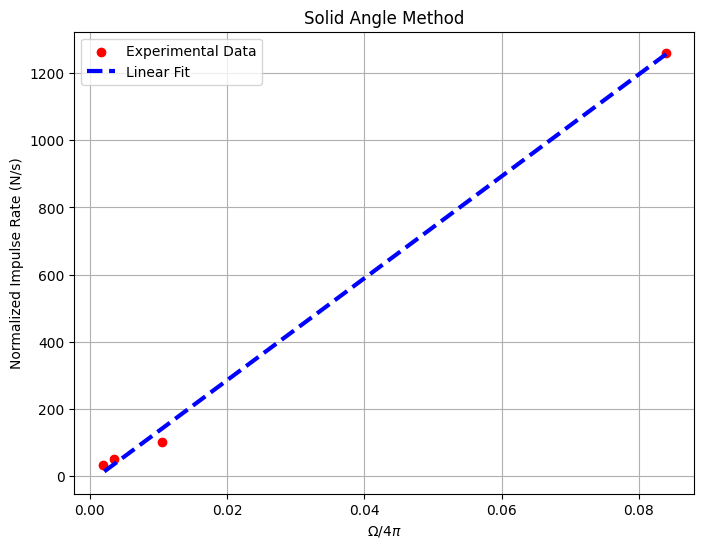

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LinearRegression

# Constants
DETECTOR_DIAMETER = 2.0  # cm
DETECTOR_EFFICIENCY = 0.2  # ε
SCHEME_FACTOR = 2.0  # S

def calculate_solid_angle(diameter, distance):
    """
    Calculate the solid angle correction factor.
    
    Parameters:
        diameter (float): Detector diameter in cm.
        distance (float): Distance between the source and detector in cm.
    
    Returns:
        float: Solid angle correction factor.
    """
    return 0.5 - 1.0 / math.sqrt(4 + (diameter / distance) ** 2)

def load_experimental_data(filename):
    """
    Load experimental data from a CSV file.
    
    Parameters:
        filename (str): Path to the CSV file.
    
    Returns:
        tuple: Arrays of time (min), distance (cm), and measured impulses (N).
    """
    data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    time = data[:, 0]  # Measurement time (min)
    distance = data[:, 1]  # Distance between source and detector (cm)
    impulse_counts = data[:, 2]  # Measured radiation impulses (N)
    return time, distance, impulse_counts

def normalize_impulse_counts(time, impulses):
    """
    Normalize impulse counts by measurement duration.
    
    Parameters:
        time (array): Measurement durations (min).
        impulses (array): Recorded impulse counts.
    
    Returns:
        array: Normalized impulse rates (impulses per second).
    """
    normalized_counts = impulses.copy()
    for i in range(len(normalized_counts)):
        if i == 0 or i == 1:
            normalized_counts[i] /= (2.0 * 60)  # Convert to per second
        else:
            normalized_counts[i] /= (3.0 * 60)  # Convert to per second
    return normalized_counts

def perform_linear_regression(x_values, y_values):
    """
    Perform linear regression on given data.
    
    Parameters:
        x_values (array): Independent variable (solid angle correction factor).
        y_values (array): Dependent variable (normalized impulse counts).
    
    Returns:
        tuple: Trained linear regression model and computed slope.
    """
    model = LinearRegression().fit(np.array(x_values).reshape(-1, 1), y_values)
    slope = model.coef_[0]
    return model, slope

def plot_results(solid_angle_factors, normalized_counts, model):
    """
    Plot the experimental data and the linear regression fit.
    
    Parameters:
        solid_angle_factors (array): Solid angle correction factors.
        normalized_counts (array): Normalized impulse counts.
        model (LinearRegression): Trained regression model.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(solid_angle_factors, normalized_counts, color='red', label="Experimental Data")
    plt.plot(solid_angle_factors, model.predict(np.array(solid_angle_factors).reshape(-1, 1)), 
             color='blue', linewidth=3, linestyle="dashed", label="Linear Fit")
    
    plt.xlabel(r'$\Omega / 4\pi$')
    plt.ylabel('Normalized Impulse Rate (N/s)')
    plt.title('Solid Angle Method')
    plt.grid(True)
    plt.legend()
    plt.show()

def main():
    """Main function to process and analyze solid angle method data."""
    
    # Load and process experimental data
    time, distances, impulse_counts = load_experimental_data('data/values.csv')

    # Compute solid angle correction factors
    solid_angle_factors = [calculate_solid_angle(DETECTOR_DIAMETER, d) for d in distances[1:]]  # Exclude first point

    # Normalize impulse counts
    normalized_counts = normalize_impulse_counts(time[1:], impulse_counts[1:])  # Exclude first point

    # Perform linear regression
    model, slope = perform_linear_regression(solid_angle_factors, normalized_counts)

    # Compute absolute activity
    absolute_activity = slope / (DETECTOR_EFFICIENCY * SCHEME_FACTOR)
    
    # Print results
    print("\n--- Solid Angle Method Analysis ---")
    print(f"Slope of regression: {slope:.5f}")
    print(f"Computed Absolute Activity (Λ): {absolute_activity:.3e} decays per second")

    # Plot results
    plot_results(solid_angle_factors, normalized_counts, model)

if __name__ == '__main__':
    main()
